### What goes into Notebook 01:
* stratified train/validation split from the training set only
* first XGBoost multiclass run on 34-class
* evaluate with accuracy, weighted F1, macro F1, and per-class report
* save:
  * label encoder
  * model
  * feature column list
  * validation metrics
* only after that, run once on the merged holdout test set

### A good practical starting point for XGBoost is:
* `objective="multi:softprob"`
* `eval_metric="mlogloss"`
* `tree_method="hist"`
* `device="cuda"`
* `n_estimators` around 300 to 600
* `max_depth` around 6 to 10
* `learning_rate` around 0.05 to 0.1
* `subsample` around 0.8
* `colsample_bytree` around 0.8

Then we tune from there.

### Cell 1 -- Imports

In [10]:
from pathlib import Path
from collections import defaultdict
import json
import math
import random
import re

import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
from xgboost import XGBClassifier

import sys
import subprocess
import xgboost as xgb
import os
import glob
import subprocess
import xgboost as xgb
import platform 



### Cell 2 -- Config

In [11]:
print("CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("NVIDIA device files:", glob.glob("/dev/nvidia*"))
paths = [
    "/usr/lib/x86_64-linux-gnu",
    "/usr/local/cuda/lib64",
    "/usr/lib/wsl/lib",
]

for p in paths:
    if os.path.exists(p):
        print(f"\n{p}")
        for f in glob.glob(os.path.join(p, "*cuda*"))[:20]:
            print(" ", f)

print("Python executable:", sys.executable)
print("Platform:", platform.platform())
print("Machine:", platform.machine())
print("cwd:", os.getcwd())

for f in ["/.dockerenv", "/proc/1/cgroup", "/etc/os-release"]:
    print(f"\n--- {f} ---")
    if os.path.exists(f):
        with open(f, "r", errors="ignore") as fh:
            print(fh.read()[:2000])
    else:
        print("missing")


SEED = 42
np.random.seed(SEED)
random.seed(SEED)

TRAIN_MANIFEST_PATH = Path("artifacts/train_manifest.csv")
MODEL_DIR = Path("artifacts/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = "label_8"
MAX_ROWS_PER_CLASS = 50_000
CHUNKSIZE = 250_000
VAL_SIZE = 0.20
XGB_DEVICE = "cuda"

FEATURE_COLUMNS = [
    "Header_Length",
    "Protocol Type",
    "Time_To_Live",
    "Rate",
    "fin_flag_number",
    "syn_flag_number",
    "rst_flag_number",
    "psh_flag_number",
    "ack_flag_number",
    "ece_flag_number",
    "cwr_flag_number",
    "ack_count",
    "syn_count",
    "fin_count",
    "rst_count",
    "HTTP",
    "HTTPS",
    "DNS",
    "Telnet",
    "SMTP",
    "SSH",
    "IRC",
    "TCP",
    "UDP",
    "DHCP",
    "ARP",
    "ICMP",
    "IGMP",
    "IPv",
    "LLC",
    "Tot sum",
    "Min",
    "Max",
    "AVG",
    "Std",
    "Tot size",
    "IAT",
    "Number",
    "Variance",
]

CUDA_VISIBLE_DEVICES = None
NVIDIA device files: []

/usr/lib/x86_64-linux-gnu
  /usr/lib/x86_64-linux-gnu/libicudata.so.74.2
  /usr/lib/x86_64-linux-gnu/libicudata.so.74

/usr/lib/wsl/lib
  /usr/lib/wsl/lib/libcuda.so
  /usr/lib/wsl/lib/libcuda.so.1
  /usr/lib/wsl/lib/libcuda.so.1.1
  /usr/lib/wsl/lib/libcudadebugger.so.1
Python executable: /home/libhead/workspace/li_research/cic_iot_2023_analysis/.venv/bin/python
Platform: Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
Machine: x86_64
cwd: /home/libhead/workspace/li_research/cic_iot_2023_analysis/notebooks

--- /.dockerenv ---
missing

--- /proc/1/cgroup ---
0::/init.scope


--- /etc/os-release ---
PRETTY_NAME="Ubuntu 24.04.4 LTS"
NAME="Ubuntu"
VERSION_ID="24.04"
VERSION="24.04.4 LTS (Noble Numbat)"
VERSION_CODENAME=noble
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/t

### Cell 3 --- Feature List and Helpers

In [12]:
train_manifest = pd.read_csv(TRAIN_MANIFEST_PATH)

class_names = sorted(train_manifest[TARGET_COL].dropna().unique())
label_to_id = {label: i for i, label in enumerate(class_names)}
id_to_label = {i: label for label, i in label_to_id.items()}

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 8
['BENIGN', 'BRUTEFORCE', 'DDOS', 'DOS', 'MIRAI', 'RECON', 'SPOOFING', 'WEB']


### Cell 4 -- Balanced Row Sampler from Training Files

In [13]:
def sample_training_rows(
    manifest_df,
    feature_columns,
    target_col="label_34",
    max_rows_per_class=50_000,
    chunksize=250_000,
    seed=42,
):
    rng = np.random.default_rng(seed)
    counters = defaultdict(int)
    parts = []

    shuffled = manifest_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    for row in shuffled.itertuples(index=False):
        label = getattr(row, target_col)

        if pd.isna(label):
            continue

        remaining = max_rows_per_class - counters[label]
        if remaining <= 0:
            continue

        path = Path(row.path)

        for chunk in pd.read_csv(path, usecols=feature_columns, chunksize=chunksize):
            for col in feature_columns:
                chunk[col] = pd.to_numeric(chunk[col], errors="coerce").astype("float32")

            chunk = chunk.replace([np.inf, -np.inf], np.nan).dropna()

            if len(chunk) == 0:
                continue

            take_n = min(remaining, len(chunk))

            if take_n < len(chunk):
                idx = rng.choice(len(chunk), size=take_n, replace=False)
                chunk = chunk.iloc[idx].copy()
            else:
                chunk = chunk.copy()

            chunk[target_col] = label
            parts.append(chunk)

            counters[label] += len(chunk)
            remaining = max_rows_per_class - counters[label]

            if remaining <= 0:
                break

    sampled_df = pd.concat(parts, ignore_index=True)
    return sampled_df, dict(counters)

### Cell 5 -- Build Sampled Training Frame

In [14]:
sampled_df, class_row_counts = sample_training_rows(
    train_manifest,
    FEATURE_COLUMNS,
    target_col=TARGET_COL,
    max_rows_per_class=MAX_ROWS_PER_CLASS,
    chunksize=CHUNKSIZE,
    seed=SEED,
)

print("Sampled shape:", sampled_df.shape)
print(pd.Series(class_row_counts).sort_values(ascending=False))

Sampled shape: (337892, 40)
MIRAI         50000
DDOS          50000
BENIGN        50000
DOS           50000
RECON         50000
SPOOFING      50000
WEB           24828
BRUTEFORCE    13064
dtype: int64


### Cell 6 -- encode labels and split

In [15]:
sampled_df = sampled_df[sampled_df[TARGET_COL].isin(class_names)].copy()

X = sampled_df[FEATURE_COLUMNS].astype("float32")
y = sampled_df[TARGET_COL].map(label_to_id).astype("int32")

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=y,
)

print(X_train.shape, X_val.shape)

(270313, 39) (67579, 39)


### Cell 7 -- Train XGBoost

In [16]:
model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(class_names),
    eval_metric="mlogloss",
    n_estimators=600,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    tree_method="hist",
    device=XGB_DEVICE,
    random_state=SEED,
    n_jobs=8,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

[0]	validation_0-mlogloss:1.93155
[50]	validation_0-mlogloss:0.48675
[100]	validation_0-mlogloss:0.37126
[150]	validation_0-mlogloss:0.34772
[200]	validation_0-mlogloss:0.33609
[250]	validation_0-mlogloss:0.32918
[300]	validation_0-mlogloss:0.32476
[350]	validation_0-mlogloss:0.32175
[400]	validation_0-mlogloss:0.31924
[450]	validation_0-mlogloss:0.31740
[500]	validation_0-mlogloss:0.31607
[550]	validation_0-mlogloss:0.31479
[599]	validation_0-mlogloss:0.31387


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


### Validation Metrics 

In [17]:
val_pred = model.predict(X_val)

val_acc = accuracy_score(y_val, val_pred)
val_f1_weighted = f1_score(y_val, val_pred, average="weighted")
val_f1_macro = f1_score(y_val, val_pred, average="macro")

print("Validation accuracy:", val_acc)
print("Validation weighted F1:", val_f1_weighted)
print("Validation macro F1:", val_f1_macro)

report_df = pd.DataFrame(
    classification_report(
        y_val,
        val_pred,
        target_names=[id_to_label[i] for i in range(len(class_names))],
        output_dict=True,
        zero_division=0,
    )
).T

display(report_df)

Validation accuracy: 0.8829518045546694
Validation weighted F1: 0.8813871116979284
Validation macro F1: 0.8434636375659692


,precision,recall,f1-score,support
BENIGN,0.708971,0.884300,0.786989,10000.000000
BRUTEFORCE,0.799630,0.496364,0.612515,2613.000000
DDOS,0.999300,0.999300,0.999300,10000.000000
DOS,0.999400,0.999000,0.999200,10000.000000
MIRAI,0.999600,0.999800,0.999700,10000.000000
RECON,0.826619,0.863900,0.844849,10000.000000
SPOOFING,0.894216,0.777700,0.831898,10000.000000
WEB,0.721992,0.630689,0.673259,4966.000000
accuracy,0.882952,0.882952,0.882952,0.882952
macro avg,0.868716,0.831382,0.843464,67579.000000


### Cell 9 -- Save Model and Metadata

In [18]:
joblib.dump(model, MODEL_DIR / "xgb_8class_baseline.joblib")

metadata = {
    "feature_columns": FEATURE_COLUMNS,
    "target_col": TARGET_COL,
    "class_names": class_names,
    "label_to_id": label_to_id,
    "max_rows_per_class": MAX_ROWS_PER_CLASS,
    "chunksize": CHUNKSIZE,
    "seed": SEED,
    "validation_accuracy": float(val_acc),
    "validation_f1_weighted": float(val_f1_weighted),
    "validation_f1_macro": float(val_f1_macro),
}

with open(MODEL_DIR / "xgb_8class_baseline_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved model and metadata.")

Saved model and metadata.


In [19]:
def canonicalize_label(raw_label):
    if pd.isna(raw_label):
        return np.nan

    s = str(raw_label).strip()
    if s == "" or s.upper() == "NAN":
        return np.nan

    s = s.replace(".pcap.csv", "").replace(".csv", "").replace(".pcap", "")

    if re.fullmatch(r"BenignTraffic\d*", s, flags=re.IGNORECASE):
        return "BENIGN"
    if s.lower() == "benign_final":
        return "BENIGN"

    s = s.upper()
    s = s.replace("-", "_").replace(" ", "_")
    s = re.sub(r"__+", "_", s).strip("_")

    alias_map = {
        "BENIGNTRAFFIC": "BENIGN",
        "BENIGN_FINAL": "BENIGN",
        "BACKDOOR_MALWARE": "BACKDOOR_MALWARE",
        "BROWSERHIJACKING": "BROWSERHIJACKING",
        "COMMANDINJECTION": "COMMANDINJECTION",
        "SQLINJECTION": "SQLINJECTION",
        "UPLOADING_ATTACK": "UPLOADING_ATTACK",
        "XSS": "XSS",
        "MITM_ARPSPOOFING": "MITM_ARPSPOOFING",
        "DNS_SPOOFING": "DNS_SPOOFING",
        "DICTIONARYBRUTEFORCE": "DICTIONARYBRUTEFORCE",
        "RECON_HOSTDISCOVERY": "RECON_HOSTDISCOVERY",
        "RECON_OSSCAN": "RECON_OSSCAN",
        "RECON_PINGSWEEP": "RECON_PINGSWEEP",
        "RECON_PORTSCAN": "RECON_PORTSCAN",
        "VULNERABILITYSCAN": "VULNERABILITYSCAN",
        "MIRAI_GREETH_FLOOD": "MIRAI_GREETH_FLOOD",
        "MIRAI_GREIP_FLOOD": "MIRAI_GREIP_FLOOD",
        "MIRAI_UDPPLAIN": "MIRAI_UDPPLAIN",
    }

    return alias_map.get(s, s)


def map_label_to_group(label_34):
    if pd.isna(label_34):
        return np.nan
    if label_34 == "BENIGN":
        return "BENIGN"
    if label_34.startswith("DDOS_"):
        return "DDOS"
    if label_34.startswith("DOS_"):
        return "DOS"
    if label_34.startswith("RECON_") or label_34 == "VULNERABILITYSCAN":
        return "RECON"
    if label_34.startswith("MIRAI_"):
        return "MIRAI"
    if label_34 in {"DNS_SPOOFING", "MITM_ARPSPOOFING"}:
        return "SPOOFING"
    if label_34 == "DICTIONARYBRUTEFORCE":
        return "BRUTEFORCE"
    if label_34 in {
        "BACKDOOR_MALWARE",
        "BROWSERHIJACKING",
        "COMMANDINJECTION",
        "SQLINJECTION",
        "UPLOADING_ATTACK",
        "XSS",
    }:
        return "WEB"
    return "UNKNOWN"


def map_label_to_binary(label_34):
    if pd.isna(label_34):
        return np.nan
    return "BENIGN" if label_34 == "BENIGN" else "MALICIOUS"

### Cell 10 -- test chunck iterator

In [20]:
TEST_ROOT = Path("../data/CIC_IOT_Dataset_2023")
test_files = sorted(TEST_ROOT.glob("Merged*.csv"))
    
print("TEST_ROOT:", TEST_ROOT.resolve())
print("Number of test files found:", len(test_files))
print("First 3 test files:", test_files[:3])

if len(test_files) == 0:
    raise RuntimeError("No test files found. Check TEST_ROOT.")

def iter_test_chunks(test_files, feature_columns, chunksize=250_000):
    usecols = feature_columns + ["Label"]

    for path in test_files:
        for chunk in pd.read_csv(path, usecols=usecols, chunksize=chunksize):
            for col in feature_columns:
                chunk[col] = pd.to_numeric(chunk[col], errors="coerce").astype("float32")

            chunk = chunk.replace([np.inf, -np.inf], np.nan).dropna(subset=feature_columns)

            chunk["label_raw"] = chunk["Label"]
            chunk["label_34"] = chunk["label_raw"].map(canonicalize_label)
            chunk["label_8"] = chunk["label_34"].map(map_label_to_group)
            chunk["label_bin"] = chunk["label_34"].map(map_label_to_binary)

            yield chunk.drop(columns=["Label"])

TEST_ROOT: /home/libhead/workspace/li_research/cic_iot_2023_analysis/data/CIC_IOT_Dataset_2023
Number of test files found: 63
First 3 test files: [PosixPath('../data/CIC_IOT_Dataset_2023/Merged01.csv'), PosixPath('../data/CIC_IOT_Dataset_2023/Merged02.csv'), PosixPath('../data/CIC_IOT_Dataset_2023/Merged03.csv')]


### Cell 11 -- incremental confusion matrix evaluation

In [21]:
def metrics_from_confusion_matrix(cm):
    total = cm.sum()
    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    support = cm.sum(axis=1)

    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp + fp) != 0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype=float), where=(tp + fn) != 0)
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(tp, dtype=float),
        where=(precision + recall) != 0,
    )

    accuracy = float(tp.sum() / total) if total > 0 else np.nan
    macro_f1 = float(np.mean(f1)) if len(f1) > 0 else np.nan
    weighted_f1 = float(np.average(f1, weights=support)) if support.sum() > 0 else np.nan

    per_class = pd.DataFrame({
        "label": [id_to_label[i] for i in range(len(class_names))],
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
    })

    return accuracy, macro_f1, weighted_f1, per_class


cm = np.zeros((len(class_names), len(class_names)), dtype=np.int64)
dropped_missing = 0
seen_rows = 0

for chunk in iter_test_chunks(test_files, FEATURE_COLUMNS, chunksize=250_000):
    valid = chunk[TARGET_COL].notna() & chunk[TARGET_COL].isin(class_names)
    dropped_missing += (~valid).sum()

    chunk = chunk.loc[valid].copy()
    if len(chunk) == 0:
        continue

    X_chunk = chunk[FEATURE_COLUMNS].astype("float32")
    y_true = chunk[TARGET_COL].map(label_to_id).to_numpy(dtype=np.int32)
    y_pred = model.predict(X_chunk).astype(np.int32)

    np.add.at(cm, (y_true, y_pred), 1)
    seen_rows += len(chunk)

print("Evaluated test rows:", seen_rows)
print("Dropped unlabeled/invalid test rows:", dropped_missing)

test_acc, test_macro_f1, test_weighted_f1, test_per_class = metrics_from_confusion_matrix(cm)

print("Test accuracy:", test_acc)
print("Test macro F1:", test_macro_f1)
print("Test weighted F1:", test_weighted_f1)

display(test_per_class.sort_values("support", ascending=False))

Evaluated test rows: 45018243
Dropped unlabeled/invalid test rows: 0
Test accuracy: 0.6045066885440198
Test macro F1: 0.4602090484165847
Test weighted F1: 0.6734205715023417


,label,precision,recall,f1,support
2,DDOS,0.873668,0.622911,0.727282,32535697
3,DOS,0.379956,0.413902,0.396203,7746340
4,MIRAI,0.995411,0.990651,0.993025,2521551
0,BENIGN,0.803710,0.782863,0.793149,1051313
5,RECON,0.026476,0.359785,0.049323,661108
6,SPOOFING,0.680065,0.337017,0.450688,465914
7,WEB,0.030104,0.729473,0.057823,23798
1,BRUTEFORCE,0.130405,0.598946,0.214179,12522


In [22]:
test_per_class.to_csv(MODEL_DIR / "xgb_8class_test_per_class.csv", index=False)

cm_df = pd.DataFrame(
    cm,
    index=[id_to_label[i] for i in range(len(class_names))],
    columns=[id_to_label[i] for i in range(len(class_names))]
)
cm_df.to_csv(MODEL_DIR / "xgb_8class_test_confusion_matrix.csv")

test_metrics = {
    "test_accuracy": float(test_acc),
    "test_macro_f1": float(test_macro_f1),
    "test_weighted_f1": float(test_weighted_f1),
    "evaluated_test_rows": int(seen_rows),
    "dropped_unlabeled_or_invalid_rows": int(dropped_missing),
}
with open(MODEL_DIR / "xgb_8class_test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=2)

print("Saved test metrics, per-class report, and confusion matrix.")

Saved test metrics, per-class report, and confusion matrix.


,feature,gain
0,Protocol Type,373.129913
1,Number,121.766235
2,Tot sum,82.924889
3,syn_flag_number,77.803658
4,UDP,72.974617
5,SSH,62.355217
6,ack_count,60.074287
7,HTTPS,49.964207
8,rst_count,39.949150
9,rst_flag_number,37.394989


Saved feature importance to artifacts/models/xgb_8class_feature_importance_gain.csv


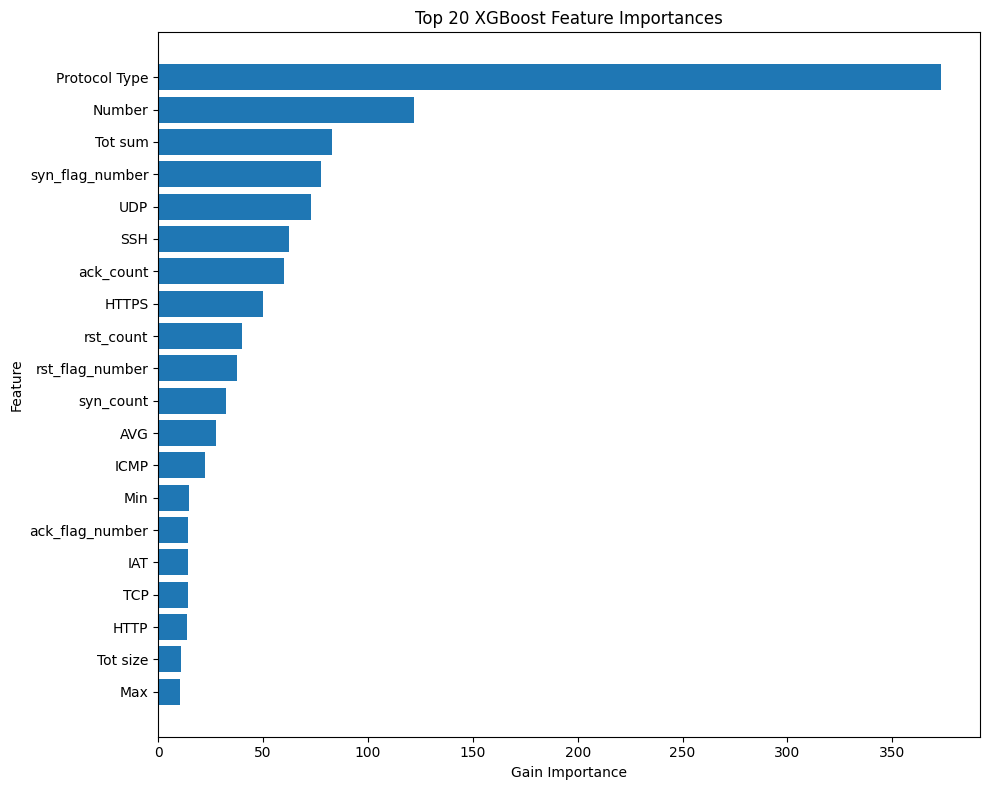

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

booster = model.get_booster()
score = booster.get_score(importance_type="gain")

if not score:
    raise RuntimeError("The model returned no feature importances.")

importance_df = pd.DataFrame({
    "feature": list(score.keys()),
    "gain": list(score.values()),
})

feature_map = {f"f{i}": col for i, col in enumerate(FEATURE_COLUMNS)}
importance_df["feature"] = importance_df["feature"].map(feature_map).fillna(importance_df["feature"])
importance_df = importance_df.sort_values("gain", ascending=False).reset_index(drop=True)

display(importance_df.head(20))

importance_path = MODEL_DIR / "xgb_8class_feature_importance_gain.csv"
importance_df.to_csv(importance_path, index=False)
print(f"Saved feature importance to {importance_path}")

top_k = importance_df.head(20).sort_values("gain")
plt.figure(figsize=(10, 8))
plt.barh(top_k["feature"], top_k["gain"])
plt.xlabel("Gain Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

Saved validation per-class report to artifacts/models/xgb_8class_validation_per_class.csv
Classes sorted by holdout F1:


,label,precision,recall,f1,support
5,RECON,0.026476,0.359785,0.049323,661108
7,WEB,0.030104,0.729473,0.057823,23798
1,BRUTEFORCE,0.130405,0.598946,0.214179,12522
3,DOS,0.379956,0.413902,0.396203,7746340
6,SPOOFING,0.680065,0.337017,0.450688,465914
2,DDOS,0.873668,0.622911,0.727282,32535697
0,BENIGN,0.803710,0.782863,0.793149,1051313
4,MIRAI,0.995411,0.990651,0.993025,2521551


Classes sorted by holdout support:


,label,precision,recall,f1,support
1,BRUTEFORCE,0.130405,0.598946,0.214179,12522
7,WEB,0.030104,0.729473,0.057823,23798
6,SPOOFING,0.680065,0.337017,0.450688,465914
5,RECON,0.026476,0.359785,0.049323,661108
0,BENIGN,0.803710,0.782863,0.793149,1051313
4,MIRAI,0.995411,0.990651,0.993025,2521551
3,DOS,0.379956,0.413902,0.396203,7746340
2,DDOS,0.873668,0.622911,0.727282,32535697


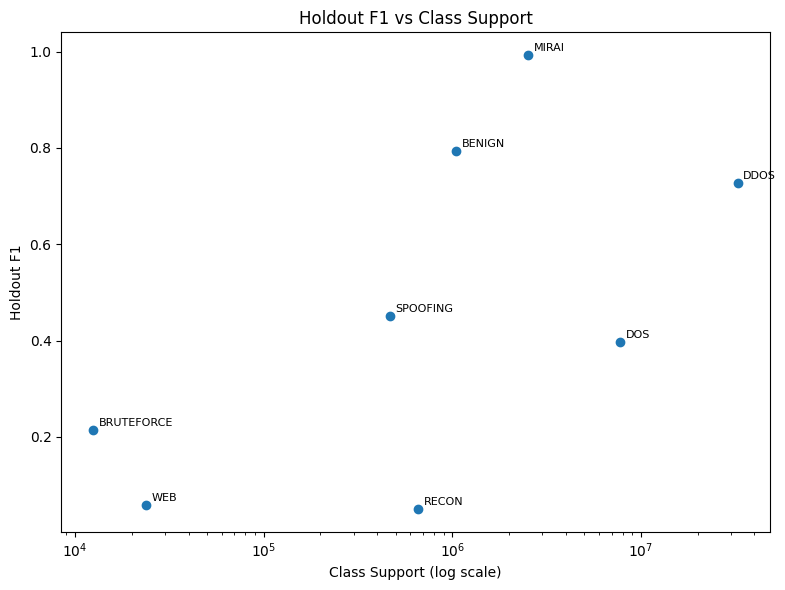

Validation vs holdout per-class comparison:


,label,precision_val,recall_val,f1_val,support_val,precision_test,recall_test,f1_test,support_test,f1_gap
5,RECON,0.826619,0.863900,0.844849,10000.0,0.026476,0.359785,0.049323,661108,0.795526
7,WEB,0.721992,0.630689,0.673259,4966.0,0.030104,0.729473,0.057823,23798,0.615436
3,DOS,0.999400,0.999000,0.999200,10000.0,0.379956,0.413902,0.396203,7746340,0.602996
1,BRUTEFORCE,0.799630,0.496364,0.612515,2613.0,0.130405,0.598946,0.214179,12522,0.398336
6,SPOOFING,0.894216,0.777700,0.831898,10000.0,0.680065,0.337017,0.450688,465914,0.381210
2,DDOS,0.999300,0.999300,0.999300,10000.0,0.873668,0.622911,0.727282,32535697,0.272018
4,MIRAI,0.999600,0.999800,0.999700,10000.0,0.995411,0.990651,0.993025,2521551,0.006675
0,BENIGN,0.708971,0.884300,0.786989,10000.0,0.803710,0.782863,0.793149,1051313,-0.006160


In [24]:
import matplotlib.pyplot as plt
import pandas as pd

validation_report_path = MODEL_DIR / "xgb_8class_validation_per_class.csv"
test_report_path = MODEL_DIR / "xgb_8class_test_per_class.csv"

if "report_df" in globals():
    val_df = report_df.copy()
else:
    raise RuntimeError("report_df is not available in the current notebook state.")

if "label" not in val_df.columns:
    val_df = val_df.reset_index().rename(columns={"index": "label"})

if "f1-score" in val_df.columns and "f1" not in val_df.columns:
    val_df = val_df.rename(columns={"f1-score": "f1"})

if "support" not in val_df.columns:
    raise RuntimeError("Validation report is missing a support column.")

val_df = val_df[val_df["label"].isin(class_names)].copy()
val_df = val_df[["label", "precision", "recall", "f1", "support"]]
val_df.to_csv(validation_report_path, index=False)

print(f"Saved validation per-class report to {validation_report_path}")

# Holdout per-class report is already saved; load it so the notebook can be rerun from disk.
test_df = pd.read_csv(test_report_path)
if "f1-score" in test_df.columns and "f1" not in test_df.columns:
    test_df = test_df.rename(columns={"f1-score": "f1"})

test_df = test_df[test_df["label"].isin(class_names)].copy()
test_df = test_df[["label", "precision", "recall", "f1", "support"]]

print("Classes sorted by holdout F1:")
display(test_df.sort_values("f1"))

print("Classes sorted by holdout support:")
display(test_df.sort_values("support"))

plt.figure(figsize=(8, 6))
plt.scatter(test_df["support"], test_df["f1"])

for _, row in test_df.iterrows():
    plt.annotate(str(row["label"]), (row["support"], row["f1"]), fontsize=8, xytext=(4, 3), textcoords="offset points")

plt.xscale("log")
plt.xlabel("Class Support (log scale)")
plt.ylabel("Holdout F1")
plt.title("Holdout F1 vs Class Support")
plt.tight_layout()
plt.show()

compare_df = val_df.merge(
    test_df,
    on="label",
    suffixes=("_val", "_test"),
)
compare_df["f1_gap"] = compare_df["f1_val"] - compare_df["f1_test"]
compare_df = compare_df.sort_values("f1_gap", ascending=False)

print("Validation vs holdout per-class comparison:")
display(compare_df)


In [25]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.utils.class_weight import compute_sample_weight
import joblib

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
weighted_model = clone(model)
weighted_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

weighted_val_pred = weighted_model.predict(X_val).astype(np.int32)
weighted_val_acc = accuracy_score(y_val, weighted_val_pred)
weighted_val_macro_f1 = f1_score(y_val, weighted_val_pred, average="macro")
weighted_val_weighted_f1 = f1_score(y_val, weighted_val_pred, average="weighted")

weighted_report_df = pd.DataFrame(
    classification_report(
        y_val,
        weighted_val_pred,
        target_names=class_names,
        output_dict=True,
    )
).transpose()

weighted_report_path = MODEL_DIR / "xgb_8class_weighted_validation_per_class.csv"
weighted_model_path = MODEL_DIR / "xgb_8class_weighted.joblib"
weighted_report_df.to_csv(weighted_report_path)
joblib.dump(weighted_model, weighted_model_path)

print("Weighted validation accuracy:", weighted_val_acc)
print("Weighted validation macro F1:", weighted_val_macro_f1)
print("Weighted validation weighted F1:", weighted_val_weighted_f1)
print(f"Saved weighted validation report to {weighted_report_path}")
print(f"Saved weighted model to {weighted_model_path}")

display(weighted_report_df)


[0]	validation_0-mlogloss:1.93460
[50]	validation_0-mlogloss:0.51451
[100]	validation_0-mlogloss:0.39606
[150]	validation_0-mlogloss:0.36963
[200]	validation_0-mlogloss:0.35622
[250]	validation_0-mlogloss:0.34768
[300]	validation_0-mlogloss:0.34246
[350]	validation_0-mlogloss:0.33818
[400]	validation_0-mlogloss:0.33494
[450]	validation_0-mlogloss:0.33230
[500]	validation_0-mlogloss:0.32999
[550]	validation_0-mlogloss:0.32798
[599]	validation_0-mlogloss:0.32642
Weighted validation accuracy: 0.8785569481643706
Weighted validation macro F1: 0.8405584942976194
Weighted validation weighted F1: 0.880299437787398
Saved weighted validation report to artifacts/models/xgb_8class_weighted_validation_per_class.csv
Saved weighted model to artifacts/models/xgb_8class_weighted.joblib


,precision,recall,f1-score,support
BENIGN,0.734227,0.843700,0.785166,10000.000000
BRUTEFORCE,0.564426,0.616915,0.589504,2613.000000
DDOS,0.999300,0.999400,0.999350,10000.000000
DOS,0.999500,0.999100,0.999300,10000.000000
MIRAI,0.999700,0.999800,0.999750,10000.000000
RECON,0.881543,0.806700,0.842463,10000.000000
SPOOFING,0.906559,0.771300,0.833477,10000.000000
WEB,0.638565,0.716875,0.675458,4966.000000
accuracy,0.878557,0.878557,0.878557,0.878557
macro avg,0.840477,0.844224,0.840558,67579.000000


In [26]:
weighted_cm = np.zeros((len(class_names), len(class_names)), dtype=np.int64)
weighted_dropped_missing = 0
weighted_seen_rows = 0

for chunk in iter_test_chunks(test_files, FEATURE_COLUMNS, chunksize=250_000):
    valid = chunk[TARGET_COL].notna() & chunk[TARGET_COL].isin(class_names)
    weighted_dropped_missing += (~valid).sum()

    chunk = chunk.loc[valid].copy()
    if len(chunk) == 0:
        continue

    X_chunk = chunk[FEATURE_COLUMNS].astype("float32")
    y_true = chunk[TARGET_COL].map(label_to_id).to_numpy(dtype=np.int32)
    y_pred = weighted_model.predict(X_chunk).astype(np.int32)

    np.add.at(weighted_cm, (y_true, y_pred), 1)
    weighted_seen_rows += len(chunk)

print("Weighted model evaluated test rows:", weighted_seen_rows)
print("Weighted model dropped unlabeled/invalid test rows:", weighted_dropped_missing)

weighted_test_acc, weighted_test_macro_f1, weighted_test_weighted_f1, weighted_test_per_class = metrics_from_confusion_matrix(weighted_cm)

print("Weighted test accuracy:", weighted_test_acc)
print("Weighted test macro F1:", weighted_test_macro_f1)
print("Weighted test weighted F1:", weighted_test_weighted_f1)

test_report_baseline = pd.read_csv(test_report_path)
if "f1-score" in test_report_baseline.columns and "f1" not in test_report_baseline.columns:
    test_report_baseline = test_report_baseline.rename(columns={"f1-score": "f1"})

test_report_baseline = test_report_baseline[test_report_baseline["label"].isin(class_names)].copy()
weighted_test_report = weighted_test_per_class.copy()

weighted_test_report_path = MODEL_DIR / "xgb_8class_weighted_test_per_class.csv"
weighted_test_cm_path = MODEL_DIR / "xgb_8class_weighted_test_confusion_matrix.csv"
weighted_test_metrics_path = MODEL_DIR / "xgb_8class_weighted_test_metrics.json"

weighted_test_report.to_csv(weighted_test_report_path, index=False)
weighted_cm_df = pd.DataFrame(
    weighted_cm,
    index=[id_to_label[i] for i in range(len(class_names))],
    columns=[id_to_label[i] for i in range(len(class_names))],
)
weighted_cm_df.to_csv(weighted_test_cm_path)

weighted_test_metrics = {
    "test_accuracy": float(weighted_test_acc),
    "test_macro_f1": float(weighted_test_macro_f1),
    "test_weighted_f1": float(weighted_test_weighted_f1),
    "evaluated_test_rows": int(weighted_seen_rows),
    "dropped_unlabeled_or_invalid_rows": int(weighted_dropped_missing),
}
with open(weighted_test_metrics_path, "w") as f:
    json.dump(weighted_test_metrics, f, indent=2)

print(f"Saved weighted test report to {weighted_test_report_path}")
print(f"Saved weighted test confusion matrix to {weighted_test_cm_path}")
print(f"Saved weighted test metrics to {weighted_test_metrics_path}")

weighted_compare = test_report_baseline.merge(
    weighted_test_report,
    on="label",
    suffixes=("_baseline", "_weighted"),
)
weighted_compare["f1_delta"] = weighted_compare["f1_weighted"] - weighted_compare["f1_baseline"]
weighted_compare = weighted_compare.sort_values("f1_delta", ascending=False)

print("Baseline vs weighted holdout per-class comparison:")
display(weighted_compare)


Weighted model evaluated test rows: 45018243
Weighted model dropped unlabeled/invalid test rows: 0
Weighted test accuracy: 0.6013699823869181
Weighted test macro F1: 0.4436334283730788
Weighted test weighted F1: 0.6722936745283851
Saved weighted test report to artifacts/models/xgb_8class_weighted_test_per_class.csv
Saved weighted test confusion matrix to artifacts/models/xgb_8class_weighted_test_confusion_matrix.csv
Saved weighted test metrics to artifacts/models/xgb_8class_weighted_test_metrics.json
Baseline vs weighted holdout per-class comparison:


,label,precision_baseline,recall_baseline,f1_baseline,support_baseline,precision_weighted,recall_weighted,f1_weighted,support_weighted,f1_delta
4,MIRAI,0.995411,0.990651,0.993025,2521551,0.995838,0.991150,0.993488,2521551,0.000463
3,DOS,0.379956,0.413902,0.396203,7746340,0.380624,0.412452,0.395899,7746340,-0.000304
2,DDOS,0.873668,0.622911,0.727282,32535697,0.873896,0.621607,0.726471,32535697,-0.000811
7,WEB,0.030104,0.729473,0.057823,23798,0.028717,0.827170,0.055507,23798,-0.002316
0,BENIGN,0.803710,0.782863,0.793149,1051313,0.849875,0.738569,0.790322,1051313,-0.002827
5,RECON,0.026476,0.359785,0.049323,661108,0.022954,0.313138,0.042772,661108,-0.006551
6,SPOOFING,0.680065,0.337017,0.450688,465914,0.684534,0.302024,0.419125,465914,-0.031564
1,BRUTEFORCE,0.130405,0.598946,0.214179,12522,0.068047,0.804664,0.125482,12522,-0.088697
